In [49]:
import numpy as np
from astropy.table import Table, vstack
import astropy.units as u
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Ellipse

In [3]:
from sklearn.ensemble import RandomForestClassifier

In [4]:
import os, sys, time, gc

In [41]:
rng = np.random.default_rng()

In [5]:
hdir = os.getenv("HOME")
pdir = os.getenv("PSCRATCH")

In [6]:
# Adding friendly to the path so we can import it in the next cell

sys.path.insert(1, f'{hdir}/codes/friendly/friendly')
sys.path.insert(1, f'{hdir}/codes/friendly')

In [7]:
from friendly.utils import FCatalog
from friendly.matchers.ellipses import FEllipse

In [8]:
%config InlineBackend.figure_format='retina'

In [9]:
plt.style.use('ggplot')

In [10]:
def fblend_generic_1d(gen_row, blend_row, add_filt=None, b_bins=None, Nbin=50, min_size=10):
    '''
    Helper function to calculate fraction of unrecognized blend as a function of `gen_row` binning.

    `gen_row` : Generic row. Any array of the same length as `blend_row` that has a variable we want to bin on
    `blend_row` : Blend label row. Array of booleans labelling an object as pure (0) or blended (1)
    `add_filt` : Additional filter. Any additional filter that should be applied along with binning. Default is no additional filter
    `b_bins` :  Blend bins. User supplied binning of `gen_row.` If no bins are provided, automatically create from minimum to maximum of `gen_row` with `Nbin` bins
    `Nbin` : Number of bins. When using automatic binning, the number of bins to use. 
    '''
    # gen_row is any measurement with the same size of blend_row

    if b_bins is None:
        b_bins = np.linspace(gen_row.min(), gen_row.max(), Nbin)
    else:
        Nbin = len(b_bins)
    
    f_blend_mag = np.zeros(Nbin)
    f_blend_err = np.zeros_like(f_blend_mag)
    f_bins = np.zeros_like(f_blend_mag)
    
    # b_bins = np.linspace(14.5, 30, 50)
    f_bins = b_bins
    b_digitize = np.digitize(gen_row, b_bins)

    num_bin = len(b_bins)
    
    for ndx in range(1, num_bin+1):
        if add_filt is None:
            filt = (b_digitize==ndx)
        else:
            filt = (b_digitize==ndx) * add_filt
        if (np.sum(filt)<=min_size):
            continue
        # num_blends = np.sum(obj_tract[filt]['unrec_blend_score'] > unrec_cutoff)
        num_blends = np.sum(blend_row[filt])
        num_objs = np.sum(filt)

        f_blend_mag[ndx-1] = num_blends/num_objs
        # Treating num_blends and num_objs as independent poisson
        f_blend_err[ndx-1] = (num_blends + num_blends ** 2 * num_objs / num_objs ** 2) ** (1 / 2) / num_objs
    
    return {'fraction': f_blend_mag, 'err': f_blend_err, 'bins': f_bins}

# Load in Data

In [11]:
def apply_box(table, bbox, RA='RA', DEC='DEC'):
    # bbox = [lower ra, upper ra, lower dec, upper dec]
    ra_filt = np.logical_and(table[RA] > bbox[0], table[RA] < bbox[1])
    dec_filt = np.logical_and(table[DEC] > bbox[2], table[DEC] < bbox[3])
    bbox_filt = np.logical_and(ra_filt, dec_filt)

    table_subset = table[bbox_filt]
    return table_subset

In [12]:
subaru = Table.read(pdir + '/data/cos_NFP.fits')
HST_all = Table.read(pdir + '/data/acs.fits')
HST = HST_all[HST_all['flags']==0]
shuang_subaru = Table.read(pdir + '/data/cos_NFPMM_newspec.fits')

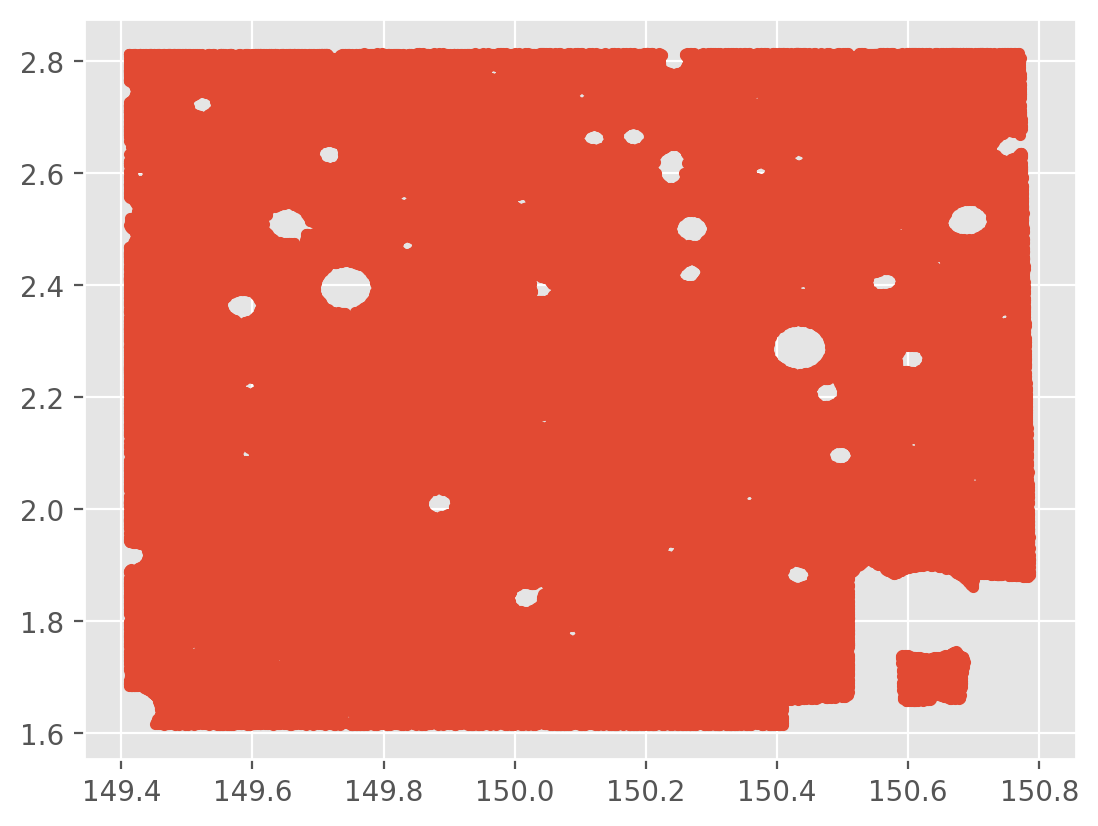

In [13]:
plt.plot(subaru['ALPHA_J2000'], subaru['DELTA_J2000'], '.')

In [14]:
# Matching on the whole data is slow since friendly is not very scalable code (currently)
# Running on a tiny subset to show that basic ideas and then remove this to get the full
# matched catalog

# bbox = [149.4, 149.8, 1.6, 2.0]
bbox = [149.4, 149.6, 1.6, 1.8]

subaru = apply_box(subaru, bbox, 'ALPHA_J2000', 'DELTA_J2000')
shuang_subaru = apply_box(shuang_subaru, bbox, 'ALPHA_J2000', 'DELTA_J2000')
HST = apply_box(HST, bbox, 'ra', 'dec')

### Catalog Set-up

Our catalog needs to be modified a bit to get things to work with friendly. 

In [15]:
subaru['fluxrad_arcsec'] = subaru['FLUX_RADIUS'] * 0.2 # Convert from pixels to arcseconds

In [16]:
# Add indexes 

subaru.add_index("NUMBER")
HST.add_index("ID")

In [17]:
# Add "ellipse" parameters (A,B, Theta) that are in units of DEGREES

# These input catalogs do not have shape paramters included so 
# we are doing the second best thing and just drawing circles (A=B=R)
# Ideally we should be using actual shape measurements to draw real ellipses
# in this section
subaru['A'] = subaru['fluxrad_arcsec'] * 1/60.**2
HST['A'] = HST['flux_radius_to_cos'] * 1/60.**2
subaru['B'] = subaru['fluxrad_arcsec'] * 1/60.**2
HST['B'] = HST['flux_radius_to_cos'] * 1/60.**2
subaru['theta'] = 0
HST['theta'] = 0

In [18]:
# Insert into the Friendly Catalog wrapper
subaru_fc = FCatalog(subaru, "NUMBER")
HST_fc = FCatalog(HST, "ID")

# Generate Candidate Matches

We use spatial coordinates and ellipse information to generate a list of candidate unrecognized blends.

In [19]:
ellipse_matcher = FEllipse(tune_params = {'search_rad': 5/(60.**2)})

In [20]:
# This is pretty slow!

ellipse_params = {'RA1': 'ALPHA_J2000', 'DEC1': 'DELTA_J2000',
                  'RA2': 'ra', 'DEC2': 'dec',
                  'A1': 'A', 'B1': 'B', 'THETA1': 'theta',
                  'A2': 'A', 'B2': 'B', 'THETA2': 'theta'}

start = time.time()
ellipse_groups, _ = ellipse_matcher(subaru_fc, HST_fc, ellipse_params, scale=1.5)
end = time.time()

print(f"Total time: {(end-start):0.2f}")

Total time: 5.13


# Prune

Using the list of candidates, we can prune this list based on what we define as blends. 
For us these are objects that are brighter than some space magnitude $m_s = 26.5$ and are within 2 magnitudes of the ground object.
Check out [this Technote](sitcomtn-128.lsst.io) for some more details.

In [21]:
# Set of helper functions to do the pruning. You probably don't need to mess with these too much.
# This will be added to friendly at some point...

def add_match_group(table, groups, match_name):
    # Add the candidate groups to the table
    ndx1_name = match_name + '_idx1'
    ndx2_name = match_name + '_idx2'

    ndx1s = []
    ndx2s = []
    for i in groups:
        ndx1s.append(i.idx1)
        ndx2s.append(i.idx2)
    table[ndx1_name] = ndx1s
    table[ndx2_name] = ndx2s

    return None

def mag_remove_id(table, mag_limit, mag_name, ndx_name='objectId'):
    # Remove entries from table that have mag_name > mag_limit
    mag_filt = table[mag_name] < mag_limit
    remove_oids = table[ndx_name][~mag_filt]
    return remove_oids

def table_removerows(table, remove_oids, ndx_name='objectId'):
    # Remove rows from a table. This gets rid of objects we don't want to study
    # when looking at population statistics but should be included in matching
    
    # Might want to think if this should be done in-place or returning a copy?
    remove_ndx = np.array([not (ndx in remove_oids) for ndx in table[ndx_name]])
    with table.index_mode('copy_on_getitem'):
        removed_table = table[remove_ndx]
    return removed_table

def table_remove_from_matches(table, remove_oids, match_name):
    # Remove entries from matches.
    
    # Might want to use set() or some other datatype to make this more
    # efficient but only relevant if this is too slow
    for i in table[match_name]:
        if len(i) > 0:
            for j in i:
                if j in remove_oids:
                    i.remove(j) #Python lists are actually convenient here!
    return None

def table_purge(table, remove_oids, match_name, ndx_name='objectId'):
    # Remove entries from matches and the rows of the table.
    removed_table = table_removerows(table, remove_oids, ndx_name)
    table_remove_from_matches(removed_table, remove_oids, match_name)
    return removed_table

def ndx2_magdiff(table, ndx2_table, match_name, mag2_name, mag_diff=2):
    # Given indexes, get the magnitudes and filter anything that is more than
    # mag_diff away from the brightest space match.
    for i,v in enumerate(table[match_name]):
        if len(v) > 1:
            ndx2_mags = ndx2_table.loc[v][mag2_name]
            ndx2_diffs = ndx2_mags - ndx2_mags.min()
            good_filt = ndx2_diffs <= mag_diff
            table[match_name][i] = [m for m,g in zip(v, good_filt) if g]
    return None

def ndx2_magdiff2(table, ndx2_table, match_name, mag1_name, mag2_name, mag_diff=2):
    # Given indexes, get the magnitudes and filter anything that is more than
    # mag_diff away from the ground object.
    for i,v in enumerate(table[match_name]):
        if i%1000==0:
            print(f"On {i}", end="\r")
        if len(v) > 1:
            ndx2_mags = ndx2_table.loc[v][mag2_name]
            ndx2_diffs = ndx2_mags - table[i][mag1_name]
            good_filt = ndx2_diffs <= mag_diff
            table[match_name][i] = [m for m,g in zip(v, good_filt) if g]
    return None

def get_unrecbl_table(table, space_table, method, ground_lim, space_lim,
                      ground_mag='i_mag', space_mag='F814_MAG',
                      ground_id='objectId', space_id='ID'):
    # Get ground objects that have no space match
    nomatch_remove_oids = np.array([k[ground_id] for k in table if len(k[f'{method}_idx2'])==0]) # Should turn this into a function...
    # Remove unmatched ground objects from the rows but not the matches!
    small_table = table_removerows(table, nomatch_remove_oids, ndx_name=ground_id)

    # Remove faint and non-matches from table
    # small_table = table_purge(table, all_roids, f'{method}_idx1', ndx_name=ground_id)

    # Get space objects in table that are fainter than space_lim
    hst_roids = mag_remove_id(space_table, space_lim, space_mag, ndx_name=space_id)
    # Remove faint space objects
    table_remove_from_matches(small_table, hst_roids, f'{method}_idx2')
    # Remove entries where the matched objects have more than 2 mag difference 
    # ndx2_magdiff2(small_table, space_table, f'{method}_idx2', mag1_name=ground_mag, mag2_name=space_mag)
    ndx2_magdiff(small_table, space_table, f'{method}_idx2', mag2_name=space_mag)
    # Label blends
    unrec_bl = np.array([len(k[f'{method}_idx2']) - len(k[f'{method}_idx1']) for k in small_table])
    small_table[f'{method}_blend'] = unrec_bl
    return small_table

In [22]:
add_match_group(subaru, ellipse_groups, 'ellipse')
# add_match_group(comcam_table, fof_groups_cc_hst, 'ellipse') # Nee

In [23]:
# This is MUCH slower!

start = time.time()
ellipse_table = get_unrecbl_table(subaru, HST, 'ellipse', 24.5, 26.5,
                                  ground_mag='ip', ground_id='NUMBER',
                                  space_mag='mag_best', space_id='ID')
end = time.time()
print(f"Total time: {(end-start):0.2f}")

Total time: 7.17


There is an issue with saving this table directly, so we break it up into two parts which works? This should be updated somepoint soon

In [24]:
# all_columns = ellipse_table.colnames
# clean_columns = all_columns[:-3] + [all_columns[-1]]

# ellipse_table_noid = ellipse_table[clean_columns]
# ellipse_table_noid.write(pdir+'/data/friendly/subaru_hst_noids.fits', format='fits', overwrite=True)

# id_table = ellipse_table['ellipse_idx1', 'ellipse_idx2']
# id_table.write(pdir+'/data/friendly/subaru_hst_ids.csv', format='pandas.csv', overwrite=True)

In [30]:
blend_col = ellipse_table['ellipse_blend']

In [31]:
shuang_blends = (shuang_subaru['b2'] > 0).astype(int)

In [32]:
ellipse_blends = (ellipse_table['ellipse_blend'] > 0).astype(int)

In [33]:
mag_bins = np.linspace(20, 26, 13)

friendly_plot = fblend_generic_1d(ellipse_table['ip'], (ellipse_table['ellipse_blend'] > 0).astype(int), b_bins=mag_bins,)
shuang_plot1 = fblend_generic_1d(shuang_subaru['ip'], (shuang_subaru['b2'] > 0).astype(int), b_bins=mag_bins)
# shuang_plot2 = fblend_generic_1d(shuang_subset['ip'], (shuang_subset['b2'] > 0).astype(int), b_bins=mag_bins)

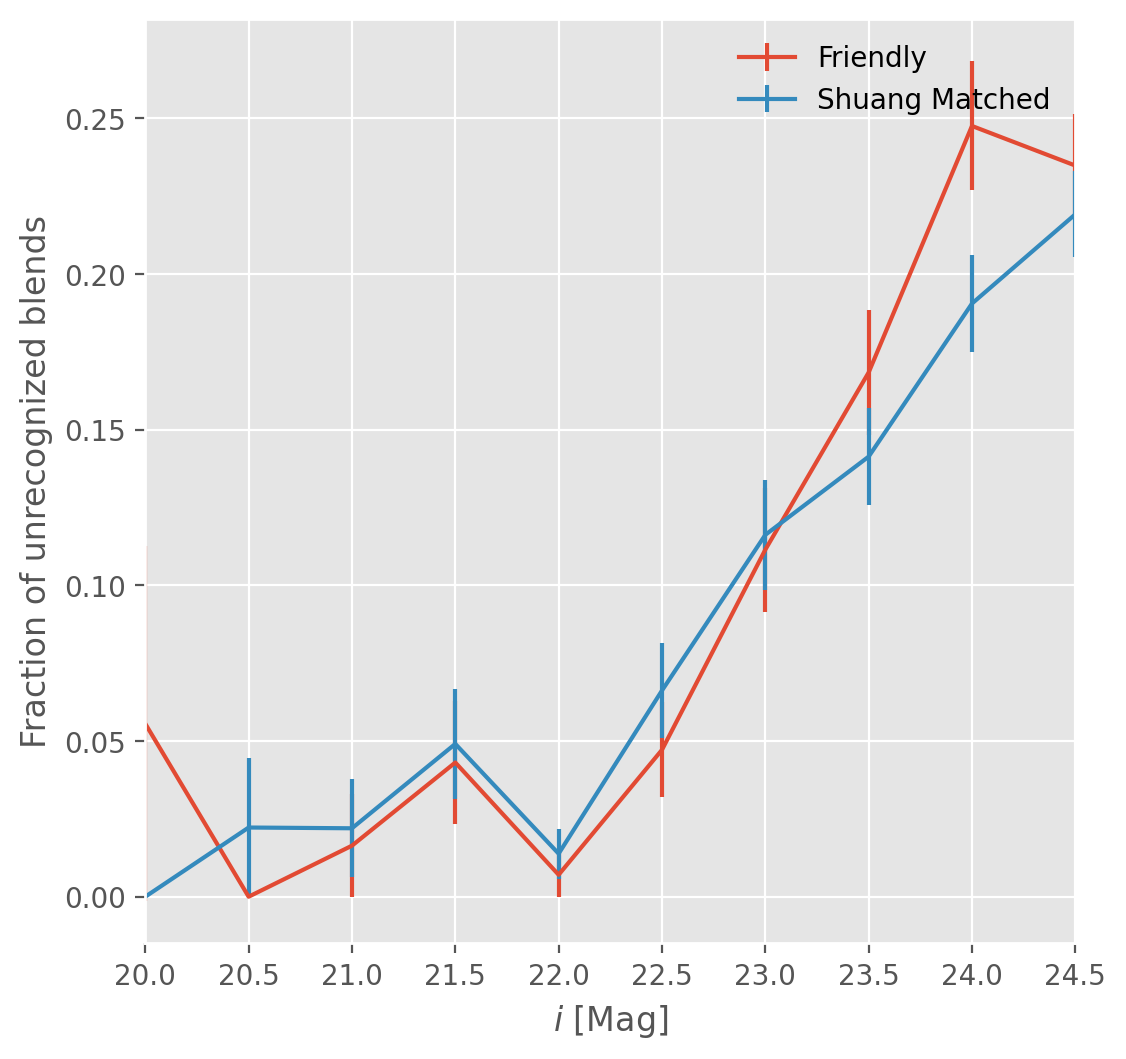

In [34]:
fig, ax = plt.subplots(1, figsize=(6,6))

ax.errorbar(friendly_plot['bins'], friendly_plot['fraction'], yerr=friendly_plot['err'], label='Friendly')
ax.errorbar(shuang_plot1['bins'], shuang_plot1['fraction'], yerr=shuang_plot1['err'], label='Shuang Matched')
# ax.errorbar(shuang_plot2['bins'], shuang_plot2['fraction'], yerr=shuang_plot2['err'], label='Shuang Subset')
ax.set_xlim(20, 24.5)
ax.set_ylabel("Fraction of unrecognized blends")
ax.set_xlabel("$i$ [Mag]")
ax.legend(frameon=False)


### Random Forest

In [35]:
def get_costrecall(test_scores, blend_filt):
    tlen = len(test_scores)

    thresholds = np.linspace(0,1,101)
    cost = np.zeros(101)
    recall = np.zeros(101)

    for i, thresh in enumerate(thresholds):
        pred_blends = test_scores > thresh

        cost[i] = np.sum(pred_blends)/tlen
        recall[i] = np.sum(pred_blends[blend_filt])/np.sum(blend_filt)
    return cost, recall, thresholds

In [38]:
blends = ellipse_table[ellipse_table['ellipse_blend'] > 0]
pure = ellipse_table[ellipse_table['ellipse_blend'] <= 0]

In [43]:
def get_split(sample, train_frac=0.5):
    # Split each sub-sample into a training + testing split
    N = len(sample)
    # Weighting the random choice between True and False by the 
    # `train_frac` input. 
    train_ndx = rng.choice([True, False], size=N, p=[train_frac, 1-train_frac])
    train = sample[train_ndx]
    test = sample[~train_ndx]
    return train, test

In [47]:
blend_train, blend_test = get_split(blends)
pure_train, pure_test = get_split(pure)

In [52]:
train = vstack((blend_train, pure_train))
test = vstack((blend_test, pure_test))

In [56]:
photom_labels = ['ALPHA_J2000', 'DELTA_J2000', 'FLUX_RADIUS', 'u', 'B', 'V', 'r', 'ip', 'zpp', 'Y', 'J', 'H']

In [77]:
train_photom = train[photom_labels].to_pandas()
test_photom = test[photom_labels].to_pandas()
train_lbl = train['ellipse_blend'] > 0 # True if it is a blend
test_lbl = test['ellipse_blend'] > 0 # True if it is a blend

In [78]:
clf = RandomForestClassifier(n_estimators=100)

In [79]:
clf.fit(train_photom, train_lbl)

RandomForestClassifier()

In [80]:
test_scores1 = clf.predict_proba(test_photom)
# blend_filt = test1_lbls.astype(bool)

In [81]:
c2, r2, thresh = get_costrecall(test_scores1[:,1], test_lbl)

In [82]:
ndx = 50
print(thresh[ndx], c2[ndx], r2[ndx])

0.5 0.014184397163120567 0.04371584699453552


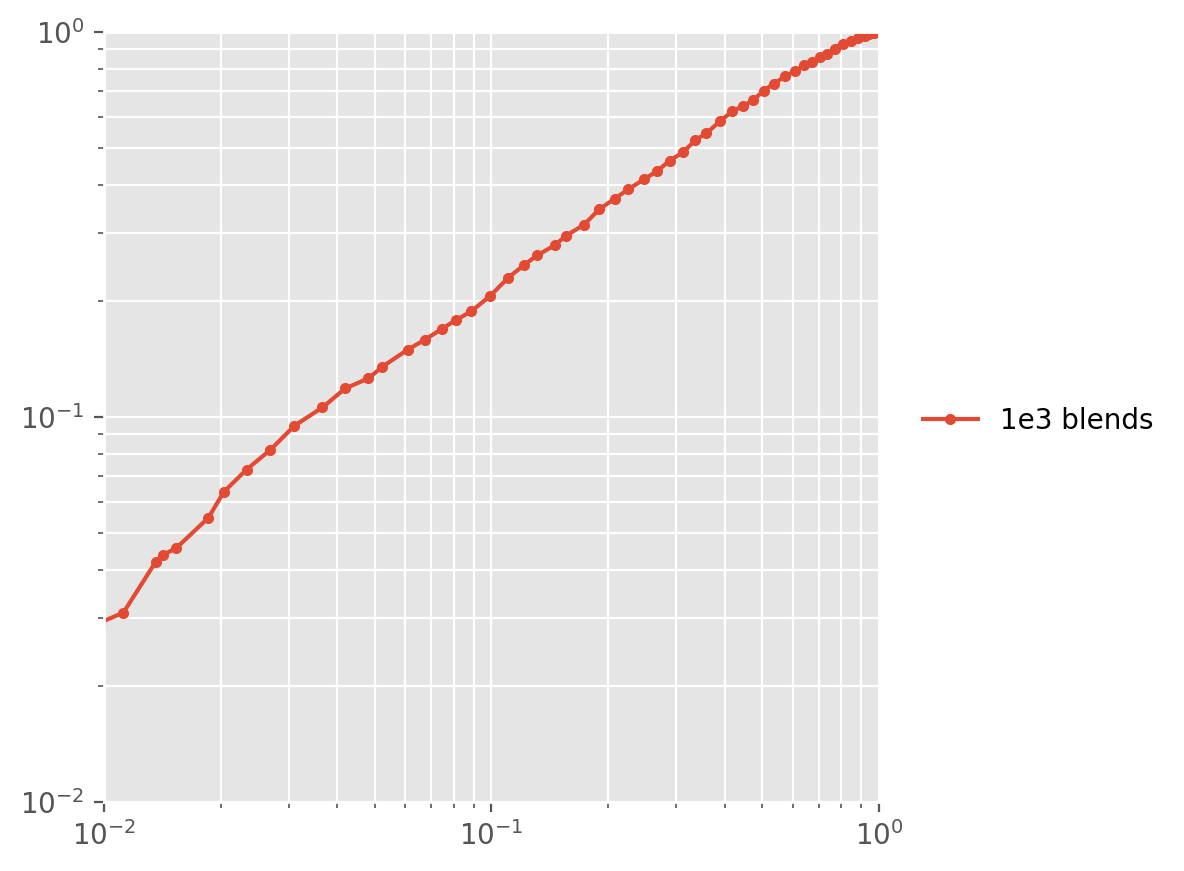

In [90]:
fig, ax = plt.subplots(1, figsize=(5,5))

# ax.plot(c1, r1, label='3e4 blends')
ax.plot(c2, r2,'.-', label='1e3 blends')

fig.legend(frameon=False, bbox_to_anchor=(1.2,.53))
ax.loglog()
ax.set_xlim([.01, 1])
ax.set_ylim([.01, 1])
ax.grid(visible=True, which='both')